In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.integrate import quad
import seaborn as sns
from scipy import stats


plt.rcParams.update({'font.size': 12})
plt.rcParams['figure.figsize'] = (10, 6)

slope: 1.88, intercept: 5.13


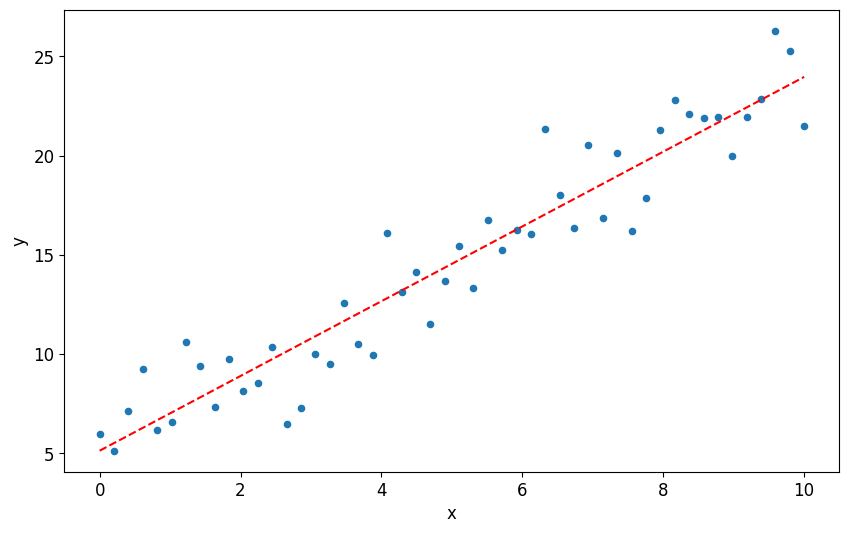

In [ ]:
# Ustawienie seed dla powtarzalności
np.random.seed(42)

# Generowanie danych: y ≈ 2x + 5 + szum
n = 50
x = np.linspace(0, 10, n)
y_true = 2 * x + 5  # prawdziwa zależność
noise = np.random.normal(0, 2, n)  # losowy szum
y = y_true + noise

# Stworzenie DataFrame
data = pd.DataFrame({'x': x, 'y': y})


slope, intercept, r_value, p_value, std_err = stats.linregress(data.x, data.y)
print(f"slope: {slope:.2f}, intercept: {intercept:.2f}")
fig, ax = plt.subplots()
data.plot(kind="scatter", x='x', y='y', ax=ax)
y_linreg = slope*x + intercept
ax.plot(x, y_linreg, 'r--')

In [ ]:
def fit_and_plot(x, y, ax):
  slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
  print(f"slope: {slope:.2f}, intercept: {intercept:.2f}")
  print(f"r: {r_value}")
  print(f"err: {std_err}")
  ax.plot(x, y, 'bo')
  x_linspace = np.linspace(min(x), max(x), 30)
  y_linreg = slope*x_linspace + intercept
  ax.plot(x_linspace, y_linreg, 'r-')

In [ ]:
np.savetxt("dane_do_fit.txt", np.c_[x, y])

In [ ]:
df = pd.read_csv("dane_do_fit.txt", delimiter=" ", header=None, names=["x", "y"])

In [ ]:
df.head()

,x,y
0,0.000000,5.993428
1,0.204082,5.131635
2,0.408163,7.111704
3,0.612245,9.270550
4,0.816327,6.164346


slope: 1.88, intercept: 5.13
r: 0.9503548762459013
err: 0.08903837899142658


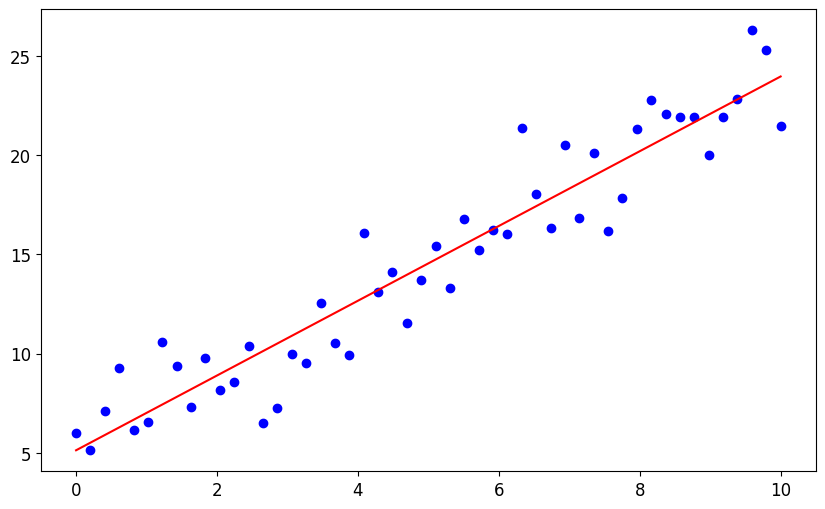

In [ ]:
fig, ax = plt.subplots()
fit_and_plot(df['x'], df['y'], ax)

## Zadanie 1

1. **Wczytaj dane:**
   - Wczytaj dane z pliku `anscombe.csv` do DataFrame za pomocą biblioteki `pandas`.
   - Przekształć dane, aby miały format:

     ```
         x1    y1    x2    y2    x3     y3   x4    y4
     0  10.0  8.04  10.0  9.14  10.0   7.46  8.0  6.58
     1   8.0  6.95   8.0  8.14   8.0   6.77  8.0  5.76
     ```

2. **Stwórz wykresy punktowe:**
   - Użyj biblioteki `matplotlib` lub `seaborn`, aby stworzyć wykresy.
   - Na każdej osi (`ax`) umieść wykres punktowy dla par `x1, y1`, `x2, y2`, `x3, y3` oraz `x4, y4`.





In [ ]:
! head /anscombe.csv

0,0,1,1,2,2,3,3
x,y,x,y,x,y,x,y
10.0,8.04,10.0,9.14,10.0,7.46,8.0,6.58
8.0,6.95,8.0,8.14,8.0,6.77,8.0,5.76
13.0,7.58,13.0,8.74,13.0,12.74,8.0,7.71
9.0,8.81,9.0,8.77,9.0,7.11,8.0,8.84
11.0,8.33,11.0,9.26,11.0,7.81,8.0,8.47
14.0,9.96,14.0,8.10,14.0,8.84,8.0,7.04
6.0,7.24,6.0,6.13,6.0,6.08,8.0,5.25
4.0,4.26,4.0,3.10,4.0,5.39,19.0,12.50


In [ ]:
anscombe_df = pd.read_csv('/anscombe.csv', header=None)
anscombe_df.head()

,0,1,2,3,4,5,6,7
0,0,0,1,1,2,2,3,3
1,x,y,x,y,x,y,x,y
2,10.0,8.04,10.0,9.14,10.0,7.46,8.0,6.58
3,8.0,6.95,8.0,8.14,8.0,6.77,8.0,5.76
4,13.0,7.58,13.0,8.74,13.0,12.74,8.0,7.71


In [ ]:
anscombe_df = pd.read_csv('/anscombe.csv', header=1)
anscombe_df.columns = ['x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4']
anscombe_df.head()

,x1,y1,x2,y2,x3,y3,x4,y4
0,10.0,8.04,10.0,9.14,10.0,7.46,8.0,6.58
1,8.0,6.95,8.0,8.14,8.0,6.77,8.0,5.76
2,13.0,7.58,13.0,8.74,13.0,12.74,8.0,7.71
3,9.0,8.81,9.0,8.77,9.0,7.11,8.0,8.84
4,11.0,8.33,11.0,9.26,11.0,7.81,8.0,8.47


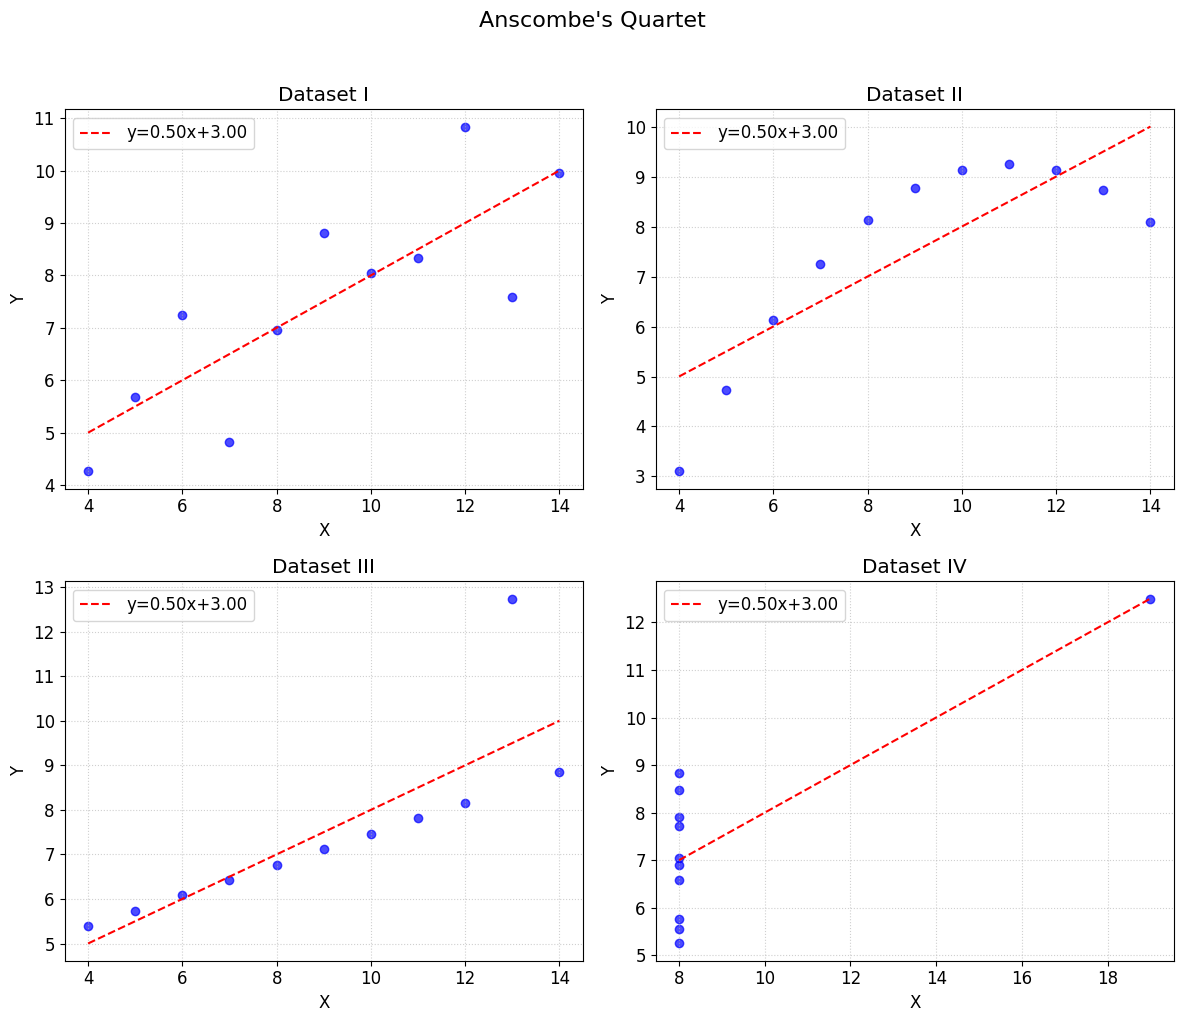

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

dataset_names = ['Dataset I', 'Dataset II', 'Dataset III', 'Dataset IV']

for i, ax in enumerate(axes):
    x_col = f'x{i+1}'
    y_col = f'y{i+1}'

    ax.scatter(anscombe_df[x_col], anscombe_df[y_col], color='blue', alpha=0.7)


    slope, intercept, r_value, p_value, std_err = stats.linregress(anscombe_df[x_col], anscombe_df[y_col])
    x_linreg = np.array([anscombe_df[x_col].min(), anscombe_df[x_col].max()])
    y_linreg = slope * x_linreg + intercept
    ax.plot(x_linreg, y_linreg, color='red', linestyle='--', label=f'y={slope:.2f}x+{intercept:.2f}')

    ax.set_title(f'{dataset_names[i]}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Anscombe\'s Quartet', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## Zadanie 2

Przeprowadź eksploracyjną analizę danych (EDA) dla zbioru danych o domach `house_train.csv`

### Загрузка данных house_train.csv

In [9]:
df = pd.read_csv('house_sales.csv', sep='\t')
df.head()

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,3.00,6,7,1991,0,0,70000,229000,98002,False
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,3.75,4,10,2005,0,0,203000,590000,98166,True
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,1.75,4,8,1947,0,0,183000,275000,98166,False
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,3.75,5,7,1966,0,0,104000,229000,98168,False
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,1.75,4,7,1948,0,0,104000,205000,98168,False


In [10]:
df.describe()

,SalePrice,PropertyID,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,SqFtTotLiving,SqFtFinBasement,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode
count,2.268700e+04,2.268700e+04,22687.000000,22687.000000,2.268700e+04,22687.000000,2.268700e+04,22687.000000,22687.000000,22687.000000,22687.000000,22687.000000,22687.000000,22687.000000,22687.000000,2.268700e+04,2.268700e+04,22687.000000
mean,5.079244e+05,4.666164e+09,392181.923569,0.901153,5.652333e+05,1.018821,1.174633e+04,2080.165734,293.233305,2.176500,3.367744,7.680963,1971.195266,102.314762,0.205801,2.203211e+05,3.004712e+05,98078.526910
std,3.466368e+05,2.877700e+09,36349.866645,0.083525,3.854029e+05,0.159752,2.901602e+04,913.742170,439.454608,0.768027,0.904379,1.180464,30.313796,440.579006,0.554216,1.829177e+05,2.265750e+05,52.342559
min,3.000000e+03,1.000102e+06,311600.000000,0.715993,3.368000e+03,1.000000,4.940000e+02,370.000000,0.000000,0.000000,0.000000,3.000000,1900.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,98001.000000
25%,3.250000e+05,2.212325e+09,360700.000000,0.828814,3.605630e+05,1.000000,4.800000e+03,1420.000000,0.000000,1.750000,3.000000,7.000000,1950.000000,0.000000,0.000000,1.070000e+05,1.720000e+05,98034.000000
50%,4.246500e+05,4.006000e+09,403200.000000,0.926471,4.713150e+05,1.000000,7.200000e+03,1910.000000,0.000000,2.250000,3.000000,7.000000,1977.000000,0.000000,0.000000,1.820000e+05,2.460000e+05,98065.000000
75%,5.850000e+05,7.417700e+09,421200.000000,0.967831,6.494110e+05,1.000000,9.794000e+03,2540.000000,580.000000,2.500000,4.000000,8.000000,2000.000000,0.000000,0.000000,2.670000e+05,3.610000e+05,98117.000000
max,1.100000e+07,9.906000e+09,435200.000000,1.000000,1.164486e+07,5.000000,1.024068e+06,10740.000000,3500.000000,8.000000,33.000000,13.000000,2015.000000,2016.000000,3.000000,5.538000e+06,5.772000e+06,98354.000000


In [11]:
df.columns

Index(['DocumentDate', 'SalePrice', 'PropertyID', 'PropertyType', 'ym',
       'zhvi_px', 'zhvi_idx', 'AdjSalePrice', 'NbrLivingUnits', 'SqFtLot',
       'SqFtTotLiving', 'SqFtFinBasement', 'Bathrooms', 'Bedrooms',
       'BldgGrade', 'YrBuilt', 'YrRenovated', 'TrafficNoise', 'LandVal',
       'ImpsVal', 'ZipCode', 'NewConstruction'],
      dtype='object')

Series([], dtype: int64)


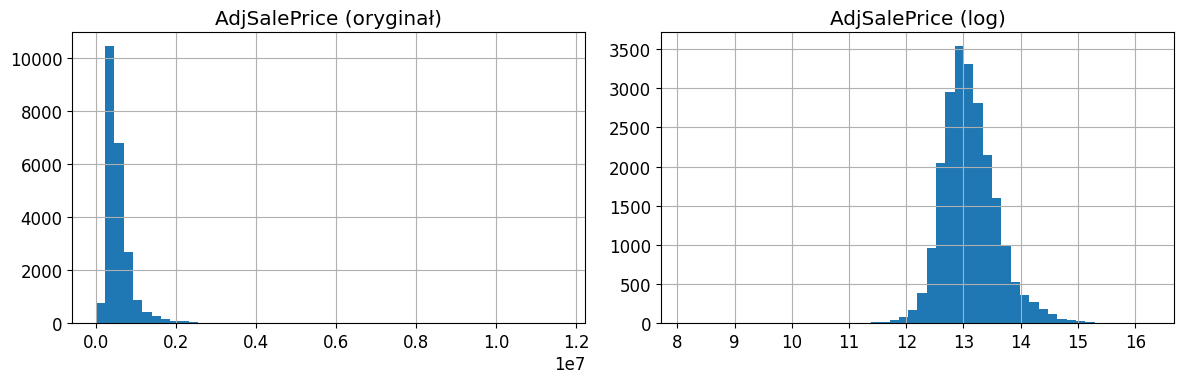


Korelacja z AdjSalePrice:
AdjSalePrice       1.000000
SalePrice          0.985465
ImpsVal            0.833368
LandVal            0.812183
SqFtTotLiving      0.695147
BldgGrade          0.675566
Bathrooms          0.529123
Bedrooms           0.312074
SqFtFinBasement    0.297716
SqFtLot            0.137147
YrRenovated        0.107782
was_renovated      0.107600
YrBuilt            0.082133
NewConstruction    0.040934
NbrLivingUnits     0.022548
TrafficNoise      -0.012253
PropertyID        -0.024586
zhvi_px           -0.044657
zhvi_idx          -0.044657
ZipCode           -0.069676
age               -0.082133
Name: AdjSalePrice, dtype: float64


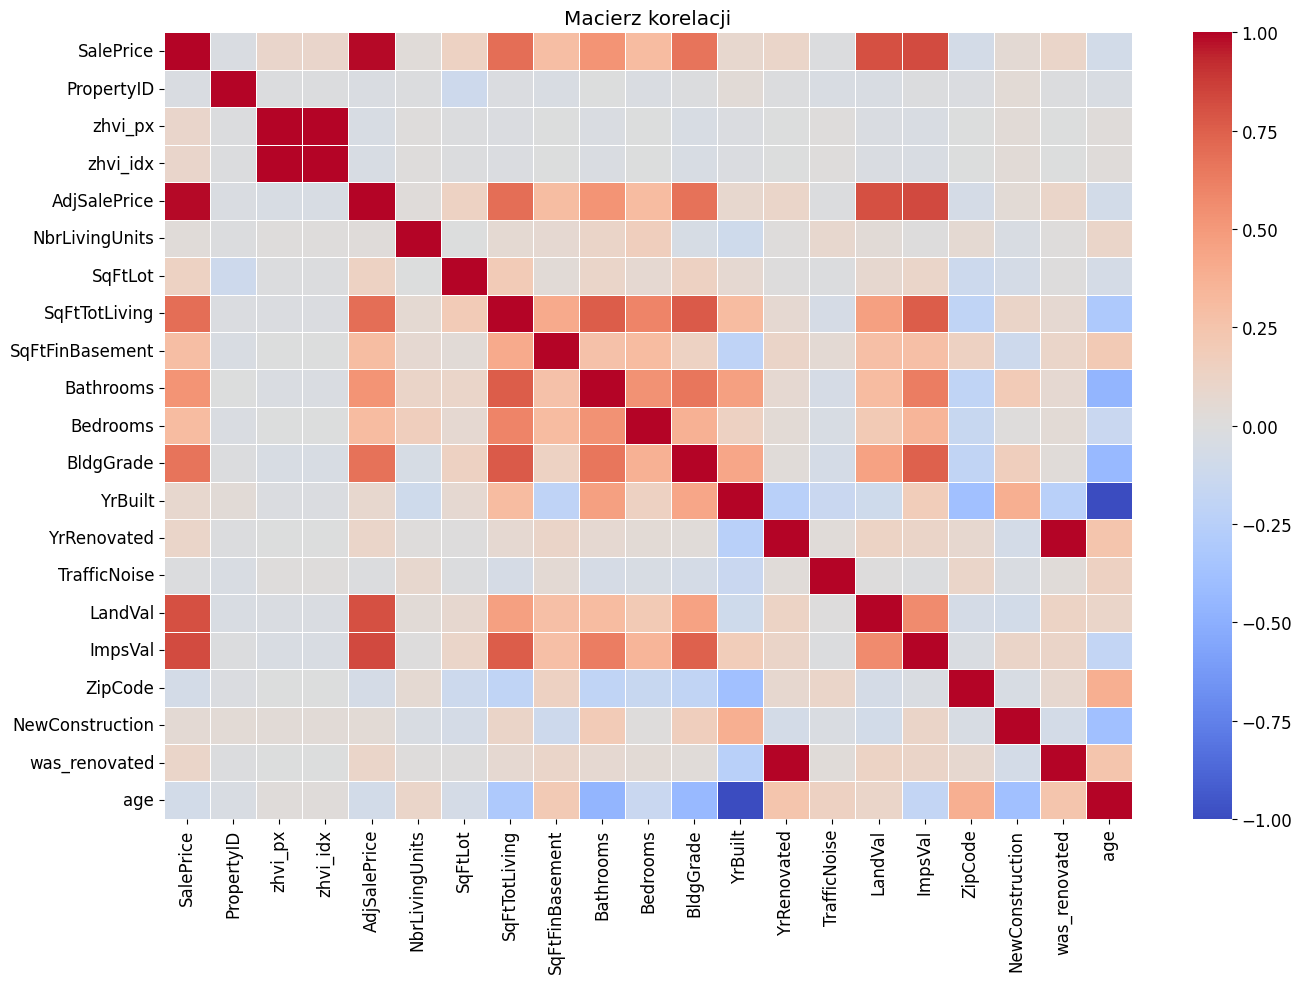

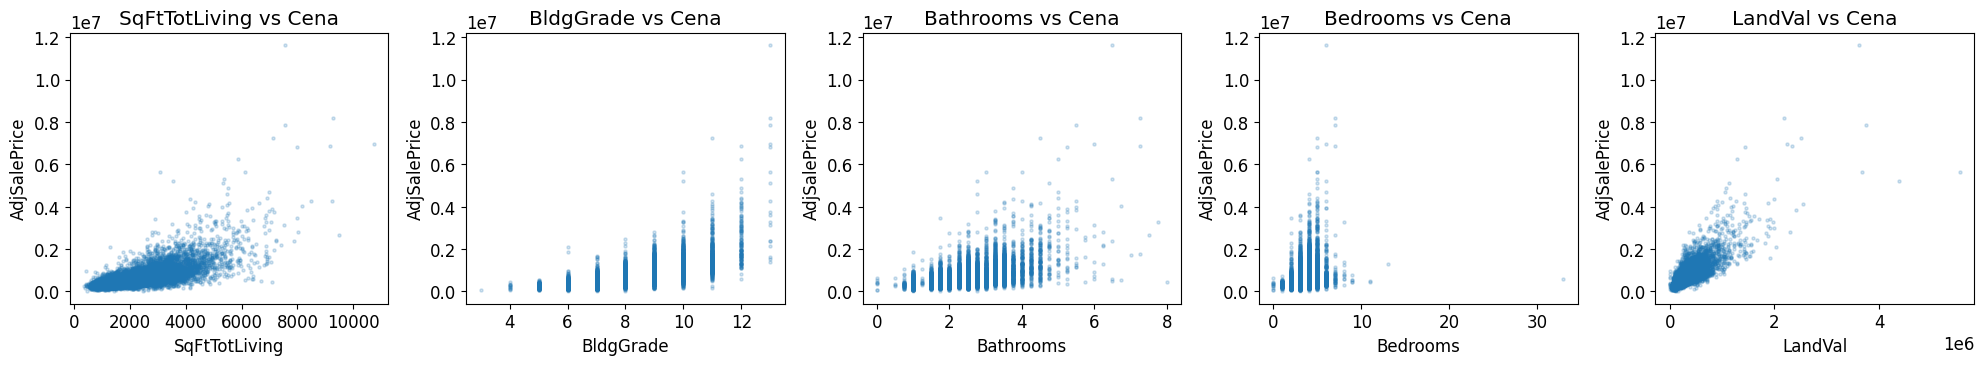

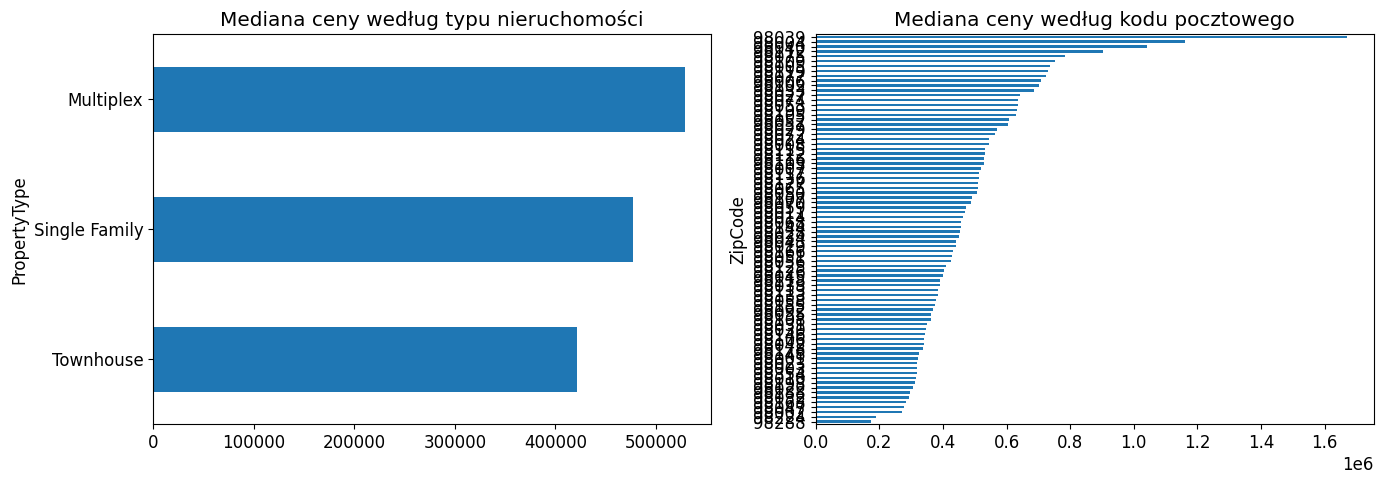

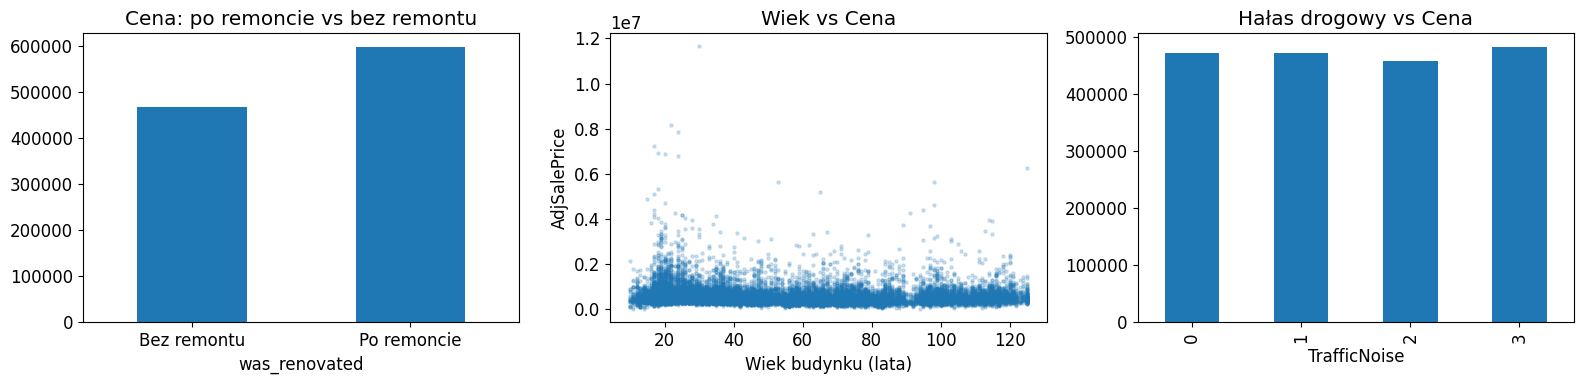

In [13]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['AdjSalePrice'].hist(bins=50, ax=axes[0])
axes[0].set_title('AdjSalePrice (oryginał)')
np.log(df['AdjSalePrice']).hist(bins=50, ax=axes[1])
axes[1].set_title('AdjSalePrice (log)')
plt.tight_layout()
plt.show()

corr = df.corr(numeric_only=True)['AdjSalePrice'].sort_values(ascending=False)
print("\nKorelacja z AdjSalePrice:")
print(corr)

plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Macierz korelacji')
plt.tight_layout()
plt.show()

top_features = ['SqFtTotLiving', 'BldgGrade', 'Bathrooms', 'Bedrooms', 'LandVal']
fig, axes = plt.subplots(1, len(top_features), figsize=(20, 4))
for ax, col in zip(axes, top_features):
    ax.scatter(df[col], df['AdjSalePrice'], alpha=0.2, s=5)
    ax.set_xlabel(col)
    ax.set_ylabel('AdjSalePrice')
    ax.set_title(f'{col} vs Cena')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.groupby('PropertyType')['AdjSalePrice'].median().sort_values().plot(kind='barh', ax=axes[0])
axes[0].set_title('Mediana ceny według typu nieruchomości')
df.groupby('ZipCode')['AdjSalePrice'].median().sort_values().plot(kind='barh', ax=axes[1])
axes[1].set_title('Mediana ceny według kodu pocztowego')
plt.tight_layout()
plt.show()

df['was_renovated'] = (df['YrRenovated'] > 0).astype(int)
df['age'] = 2025 - df['YrBuilt']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df.groupby('was_renovated')['AdjSalePrice'].median().plot(kind='bar', ax=axes[0])
axes[0].set_title('Cena: po remoncie vs bez remontu')
axes[0].set_xticklabels(['Bez remontu', 'Po remoncie'], rotation=0)

axes[1].scatter(df['age'], df['AdjSalePrice'], alpha=0.2, s=5)
axes[1].set_xlabel('Wiek budynku (lata)')
axes[1].set_ylabel('AdjSalePrice')
axes[1].set_title('Wiek vs Cena')

df.groupby('TrafficNoise')['AdjSalePrice'].median().plot(kind='bar', ax=axes[2])
axes[2].set_title('Hałas drogowy vs Cena')

plt.tight_layout()
plt.show()